
TASK 1 - PROBLEM IDENTIFICATION
---
Selected Problem Type:

Image classification

I choose this beacuse the dataset contains images belonging to four categories:

1. Normal
2. Dent
3. Scratch
4. Stain

Each image belongs to exactly one category.

The objective is to train a CNN model that can automatically classify the defect type present in an image.

Since the assignment gave us task which involves assigning one label to each image, this dataset represents an: IMAGE CLASSIFICATION PROBLEM



In [14]:
# ==========================================
# IMPORTING REQUIRED LIBRARIES
# ==========================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries Imported Successfully")


Libraries Imported Successfully



Number of Classes: 4
Classes Found: ['dent', 'normal', 'scratch', 'stain']
dent --> 120 images
normal --> 120 images
scratch --> 120 images
stain --> 120 images

========== DISPLAYING SAMPLE IMAGES ==========



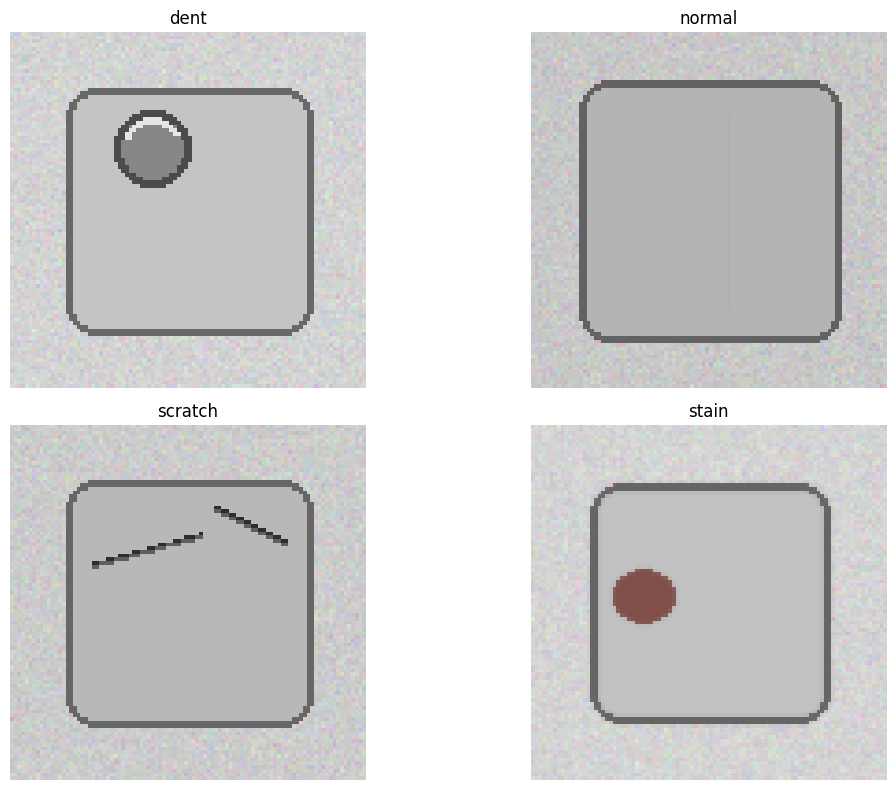


========== CHECKING IMAGE DIMENSIONS ==========

dent --> Image Shape: (96, 96, 3)
normal --> Image Shape: (96, 96, 3)
scratch --> Image Shape: (96, 96, 3)
stain --> Image Shape: (96, 96, 3)

========== CHECKING DATASET IMBALANCE ==========

dent --> 120 images
normal --> 120 images
scratch --> 120 images
stain --> 120 images


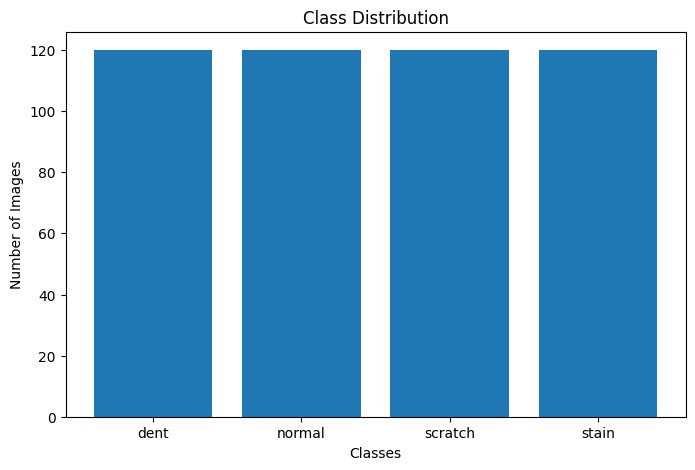

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.

Class Labels:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}

========== CNN Model SUMMARY ==========



c:\Users\Shiv Kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 863ms/step - accuracy: 0.2865 - loss: 1.4142 - val_accuracy: 0.2500 - val_loss: 1.3845
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 742ms/step - accuracy: 0.2552 - loss: 1.3842 - val_accuracy: 0.2500 - val_loss: 1.3690
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 798ms/step - accuracy: 0.3568 - loss: 1.3169 - val_accuracy: 0.5729 - val_loss: 1.2295
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 591ms/step - accuracy: 0.4922 - loss: 1.1398 - val_accuracy: 0.5729 - val_loss: 0.9630
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - accuracy: 0.6042 - loss: 0.8872 - val_accuracy: 0.6875 - val_loss: 0.7591
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.6771 - loss: 0.6630 - val_accuracy: 0.7917 - val_loss: 0.5426
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 510ms/step - accuracy: 0.7552 - loss: 0.5681 - val_accuracy: 0.8750 - val_loss: 0.4229
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 572ms/step - accuracy: 0.8281 - loss: 0.4452 - val_accuracy: 

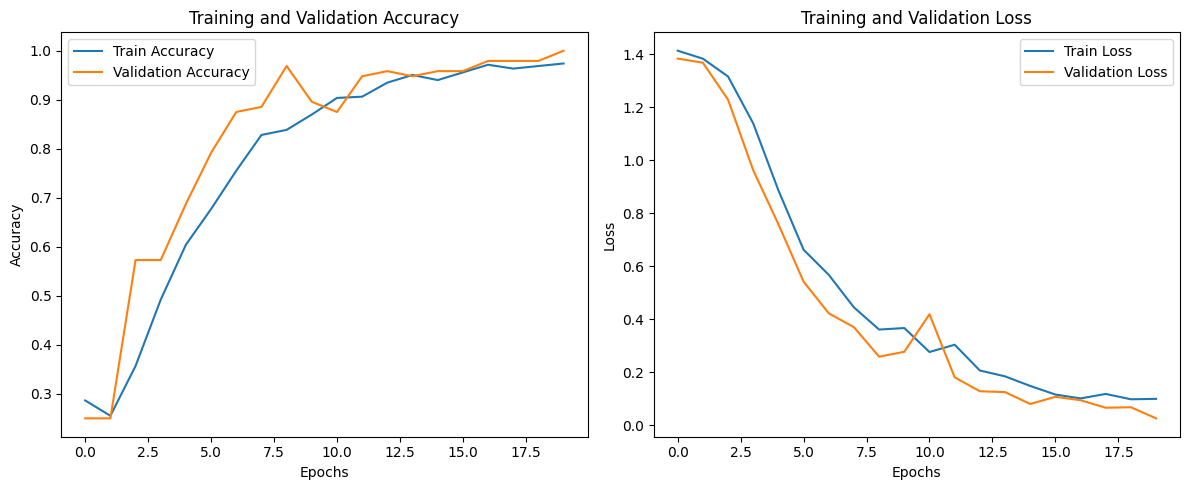


Evaluating Model Performance...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.9688 - loss: 0.0728

Testing Loss: 0.0728
Testing Accuracy: 0.9688
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step


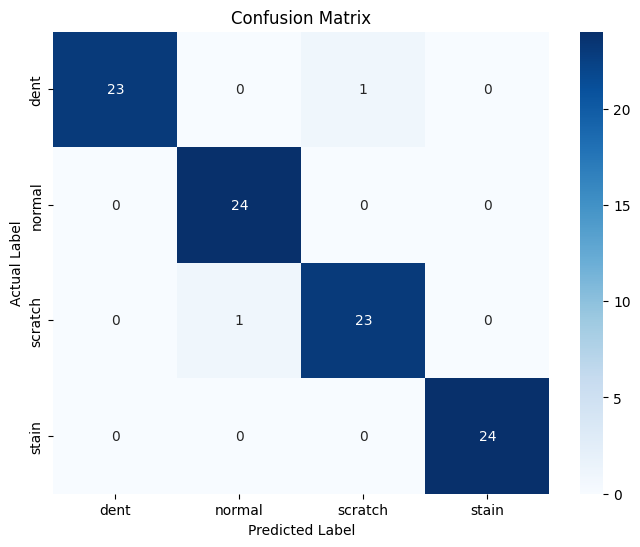


========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

        dent       1.00      0.96      0.98        24
      normal       0.96      1.00      0.98        24
     scratch       0.96      0.96      0.96        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96


========== DISPLAYING SAMPLE PREDICTIONS ==========

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step


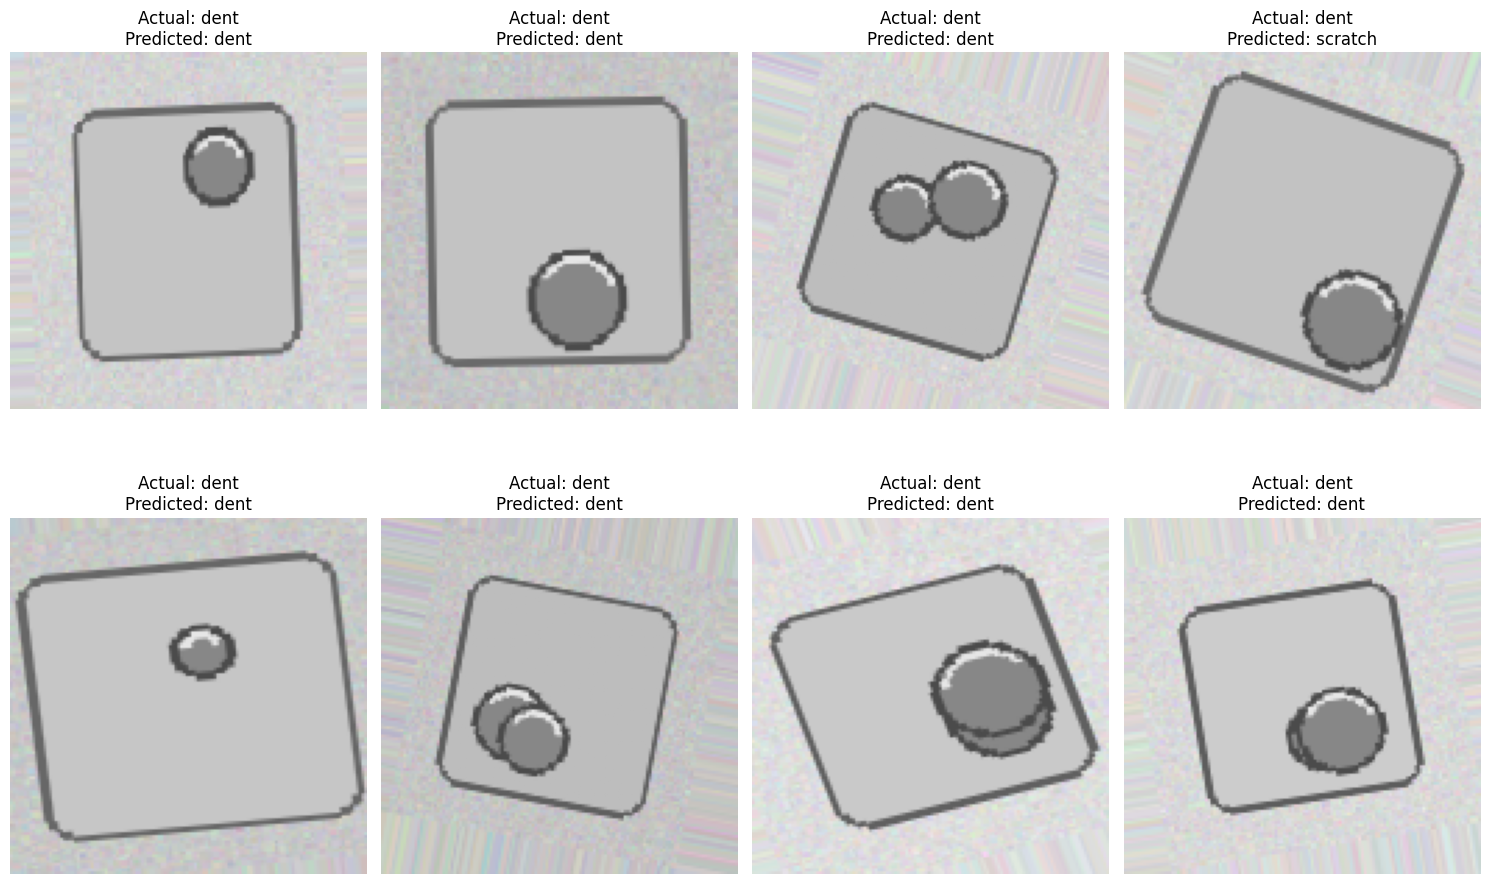

In [15]:
# ==========================================
# TASK 2: DATASET EXPLORATION
# ==========================================

dataset_path = "images"

# Getting only folder names and ignoring hidden/system files
classes = [

    folder for folder in os.listdir(dataset_path)

    if os.path.isdir(os.path.join(dataset_path, folder))
]

# Printing the number of classes and the class names 
print(f"\nNumber of Classes: {len(classes)}")
print(f"Classes Found: {classes}")

# Dictionary to store image counts for each class 
class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
   
    
    # Count number of images
    num_images = len(os.listdir(class_path))
    class_counts[class_name] = num_images
    print(f"{class_name} --> {num_images} images")

# ------------------------------------------
# DISPLAYING SAMPLE IMAGES FROM EACH CLASS
print("\n========== DISPLAYING SAMPLE IMAGES ==========\n")

plt.figure(figsize=(12, 8))
for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    
    # Get first image from the class
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    img = plt.imread(image_path)

    # Display the image
    plt.subplot(2, 2, i + 1 )
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# ------------------------------------------
# CHECKING IMAGE DIMENSIONS
print("\n========== CHECKING IMAGE DIMENSIONS ==========\n")

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    img = plt.imread(image_path)
    print(f"{class_name} --> Image Shape: {img.shape}")

# ------------------------------------------
# CHECKING DATASET IMBALANCE
print("\n========== CHECKING DATASET IMBALANCE ==========\n")

for class_name, count in class_counts.items():

    print(f"{class_name} --> {count} images")

# Plotting the class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()


# ==========================================
# TASK 3: IMAGE PREPROCESSING
# ==========================================

# Image dimensions and batch size
IMG_WIDTH = 128
IMG_HEIGHT = 128

BATCH_SIZE = 32


# Data augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,     # Normalization pixels
    validation_split=0.2,  # Validation split

    # Data Augmentation Parameters
    rotation_range=20,     
    zoom_range=0.2,
    horizontal_flip=True,
)

# Training dataset
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
)

# Validation dataset
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,  # Important for evaluation
)

# PRINTING CLASS LABELS
print("\nClass Labels:")
print(train_generator.class_indices)


# ==========================================
# TASK 4: CNN Model Creation
# ==========================================

#Creating CNN Model
model = Sequential()

# Input Layer
model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# ----------------------------------
# Convolutional Layer 1

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )       
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# -----------------------------------
# Convolutional Layer 2
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# -----------------------------------
# Convolutional Layer 3

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# -----------------------------------
# Flattening Layer

model.add(Flatten())

# -----------------------------------
# Dense Layer 
model.add(Dense(128, activation="relu"))

# Dropout Layer (Helps reduce overfitting)
model.add(Dropout(0.5))

# -----------------------------------
# Output Layer 

# 4 classes = softmax activation
model.add(Dense(4, activation="softmax"))

# Compiling the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Model Summary
print("\n========== CNN Model SUMMARY ==========\n")
model.summary()

# ==========================================
# TASK 5: MODEL TRAINING AND EVALUATION
# ==========================================

# Training the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,  
)

print("\nTraining Completed Successfully!")

# -----------------------------------
# Training Accuracy And Loss Visualization

plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Graph    
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")   
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

# Save graph
plt.savefig("results/accuracy_loss_curves.png")

plt.show()

# -----------------------------------
# Testing Performance

print("\nEvaluating Model Performance...")

loss, accuracy = model.evaluate(validation_generator)
print(f"\nTesting Loss: {loss:.4f}")
print(f"Testing Accuracy: {accuracy:.4f}")

# -----------------------------------
# Confusion Matrix

# predicting classes
predictions = model.predict(validation_generator)

# Converting predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Actual class labels
true_classes = validation_generator.classes

# Class labels
class_labels = list(validation_generator.class_indices.keys())

# Creating confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")   
plt.ylabel("Actual Label")

# Save confusion matrix
plt.savefig("results/confusion_matrix.png")

plt.show()

# ------------------------------------
# Classification Report

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels,
    )
)

# -------------------------------------
# SAMPLE PREDICTIONS On TEST IMAGES

print("\n========== DISPLAYING SAMPLE PREDICTIONS ==========\n")

images, labels = next(validation_generator)

# Predict Images
preds = model.predict(images)

# Convert probabilities into labels
predicted_labels = np.argmax(preds, axis=1)

# Actual labels
actual_labels = np.argmax(labels, axis=1)

# Plot predictions
plt.figure(figsize=(15,10))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    actual_class = class_labels[actual_labels[i]]
    predicted_class = class_labels[predicted_labels[i]]

    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
    plt.axis('off')

plt.tight_layout()

# Save predicted image
plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()


# ===========================================
# END OF ASSIGNMENT
# ===========================================


TASK 7: BUSINESS USE CASE MAPPING
---

This computer vision solution can be used for automatic surface-level defect detection in the manufacturing domain. The system is capable of identifying different types of product conditions such as dents, scratches, stains, and normal surfaces using image classification techniques.

In many industries, product inspection is usually done manually, which can be time-consuming and may lead to human errors. By using a CNN-based computer vision model, the inspection process can be automated and defects can be detected more quickly and accurately.

The system can identify:

- Dent defects
- Scratches
- Stains
- Normal products

Benefits from this:
- Faster quality inspection
- Reduced human error
- Improved product quality
- Lower operational costs
- Better consistency in product checking